1. Data loading and initial inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create the necessary folders
os.makedirs("figures", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# Load the csv
df = pd.read_csv('data/raw/StudentPerformanceFactors.csv') 

In [2]:
# Create a DF to track when these exams might have taken place
exam_info = pd.DataFrame({
    'Exam_Period': ['Midterm', 'Final'],
    'Date_String': ['2023-10-15', '2023-12-10']
})

display(exam_info)

exam_info['Date'] = pd.to_datetime(exam_info['Date_String'], errors='coerce')

,Exam_Period,Date_String
0,Midterm,2023-10-15
1,Final,2023-12-10


In [3]:
display(df.iloc[:3, :5])

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities
0,23,84,Low,High,No
1,19,64,Low,Medium,No
2,24,98,Medium,Medium,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


2. Cleaning and transformation

In [6]:
# Fill missing data with the constant 'Unknown'
df['Teacher_Quality'] = df['Teacher_Quality'].fillna('Unknown')

# Drop rows where data is missing
df = df.dropna(subset=['Parental_Education_Level', 'Distance_from_Home'])

# Force 'Previous_Scores' to become numeric and na if the input cant be turned into a number
df['Previous_Scores'] = pd.to_numeric(df['Previous_Scores'], errors='coerce')

# Type conversion to 'Category'
df['Parental_Involvement'] = df['Parental_Involvement'].astype('category')

# Filter for students in Public schools with high attendance
public_high_school_attendance = df[(df['School_Type'] == 'Public') & (df['Attendance'] > 90)]
display(public_high_school_attendance.head())


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72
21,19,99,Medium,High,No,6,84,Medium,Yes,1,Medium,High,Public,Neutral,3,No,High School,Near,Male,72
26,13,91,Low,Medium,No,6,90,Medium,Yes,1,High,Medium,Public,Negative,2,Yes,High School,Moderate,Female,65


In [7]:
# Use .loc to create a new flag based on a condition
df.loc[df['Hours_Studied'] >= 20, 'Study_Commitment'] = 'High'
df.loc[df['Hours_Studied'] < 20, 'Study_Commitment'] = 'Normal'

# Categorize 'Attendance' into 'Good' (>80) and 'Poor' (<=80)
df['Attendance_Status'] = np.where(df['Attendance'] > 80, 'Good', 'Poor')

# Grouping and Multi-column Aggregations
grouped = df.groupby(["Parental_Education_Level", "Gender"])["Exam_Score"].agg(["count", "mean"]).reset_index()
display(grouped)

,Parental_Education_Level,Gender,count,mean
0,College,Female,841,67.397146
1,College,Male,1123,67.299199
2,High School,Female,1342,66.937407
3,High School,Male,1851,66.863857
4,Postgraduate,Female,544,67.889706
5,Postgraduate,Male,749,68.030708


In [8]:
# Turn data into a pivot table
pivot_df = grouped.pivot_table(index="Parental_Education_Level", columns="Gender", values="mean")
print("Mean Exam Score by Parent Education and Gender")
display(pivot_df)

# Export intermediate cleaned results
df.to_csv('data/processed/Cleaned_StudentPerformanceFactors.csv', index=False)

Mean Exam Score by Parent Education and Gender


Gender,Female,Male
Parental_Education_Level,,
College,67.397146,67.299199
High School,66.937407,66.863857
Postgraduate,67.889706,68.030708


3. Descriptive statistics and simple EDA

In [9]:
# Display columns with only numbers and describe them
numeric_cols = df.select_dtypes(include=[np.number]).columns
display(df[numeric_cols].describe())

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6450.000000,6450.000000,6450.000000,6450.000000,6450.000000,6450.000000,6450.000000
mean,19.975504,79.995504,7.033953,75.091938,1.496124,2.971938,67.246512
std,5.991338,11.551491,1.468413,14.391781,1.233255,1.028507,3.904148
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,101.000000


In [10]:
# Descriptive stats by group for a categorical variable
display(df.groupby('Access_to_Resources')['Exam_Score'].mean())

Access_to_Resources
High      68.096724
Low       66.209953
Medium    67.153348
Name: Exam_Score, dtype: float64

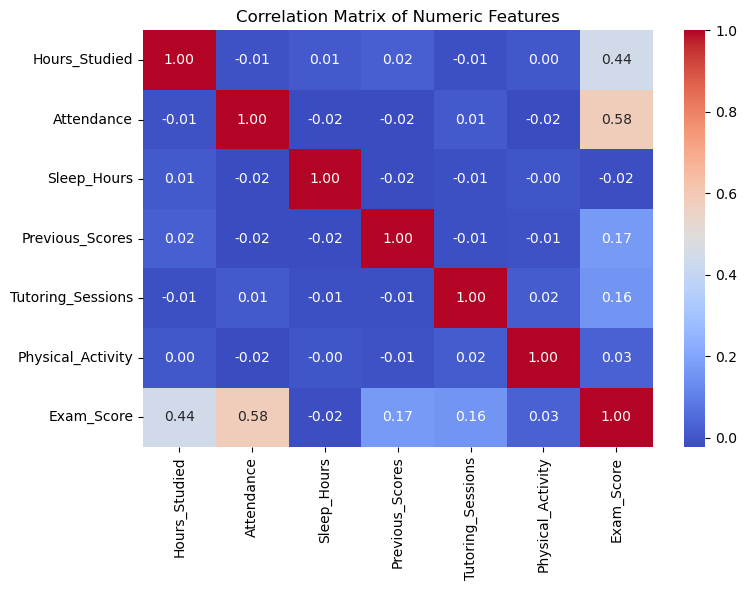

In [11]:
# Correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)